# Kuidas edeneb jäätise müümine?

In [2]:
!pip3 install prophet

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 12.1 MB 4.6 MB/s eta 0:00:01
     |████████████████████████████████| 1.3 MB 2.5 MB/s eta 0:00:01
     |████████████████████████████████| 99 kB 4.7 MB/s eta 0:00:011
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [4]:
import pandas as pd
import numpy as np
from prophet import Prophet
import matplotlib.pyplot as plt
from datetime import datetime
import json

In [5]:


# Andmed - maksustatav käive (€) pööritud kronoloogilisele järjestusele
data = {
    'kuupäev': [
        '2017-01-01', '2017-04-01', '2017-07-01', '2017-10-01',
        '2018-01-01', '2018-04-01', '2018-07-01', '2018-10-01',
        '2019-01-01', '2019-04-01', '2019-07-01', '2019-10-01',
        '2020-01-01', '2020-04-01', '2020-07-01', '2020-10-01',
        '2021-01-01', '2021-04-01', '2021-07-01', '2021-10-01',
        '2022-01-01', '2022-04-01', '2022-07-01', '2022-10-01',
        '2023-01-01', '2023-04-01', '2023-07-01', '2023-10-01',
        '2024-01-01', '2024-04-01', '2024-07-01', '2024-10-01',
        '2025-01-01', '2025-04-01', '2025-07-01', '2025-10-01',
        '2026-01-01', '2026-04-01'
    ],
    'käive': [
        7314233, 9873154, 11216327, 7101418,
        7146490, 11142578, 12800691, 7184931,
        7193612, 10624073, 12282518, 7601251,
        7673900, 9740128, 12471730, 7279196,
        7557987, 10985984, 13382517, 7972135,
        8089268, 11955605, 15022480, 8520696,
        8846334, 14093273, 15616387, 9333125,
        7829471, 12645391, 13787870, 6999717,
        7559059, 12090332, 13298972, 7438868,
        7061878, 12550080
    ]
}

df = pd.DataFrame(data)
df['ds'] = pd.to_datetime(df['kuupäev'])
df['y'] = df['käive']
df = df[['ds', 'y']].copy()

print("📊 Balbiino jäätise tehas - käibe analüüs")
print("=" * 60)
print(f"Andmete ulatusA: {df['ds'].min().strftime('%Y-%m-%d')} kuni {df['ds'].max().strftime('%Y-%m-%d')}")
print(f"Andmepunktide arv: {len(df)} kvartali")
print(f"Keskmine käive: €{df['y'].mean():,.0f}")
print()



📊 Balbiino jäätise tehas - käibe analüüs
Andmete ulatusA: 2017-01-01 kuni 2026-04-01
Andmepunktide arv: 38 kvartali
Keskmine käive: €10,033,780



In [11]:
# Fitame Prophet mudeli
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative',
    seasonality_prior_scale=10,
    interval_width=0.95
)

model.fit(df)



15:35:00 - cmdstanpy - INFO - Chain [1] start processing
15:35:00 - cmdstanpy - INFO - Chain [1] done processing


In [12]:
# Teeme prognoosi järgmise 8 kvartali jaoks
future = model.make_future_dataframe(periods=8, freq='QS')
forecast = model.predict(future)

# Prognoos
prognoos_periood = forecast[forecast['ds'] > df['ds'].max()][['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
prognoos_periood['kvartal'] = prognoos_periood['ds'].apply(lambda x: f"{x.year} Q{(x.month-1)//3 + 1}")

print("🔮 PROGNOOS (järgmise 2 aasta käive)")
print("=" * 60)
for idx, row in prognoos_periood.iterrows():
    print(f"{row['kvartal']:>8} | €{row['yhat']:>11,.0f} | Intervall: €{row['yhat_lower']:>11,.0f} ... €{row['yhat_upper']:>11,.0f}")

print()
print("📈 Komponentide analüüs")
print("=" * 60)



🔮 PROGNOOS (järgmise 2 aasta käive)
 2026 Q3 | € 13,346,403 | Intervall: € 12,646,020 ... € 14,050,346
 2026 Q4 | €  7,690,441 | Intervall: €  6,963,714 ... €  8,409,450
 2027 Q1 | €  7,355,027 | Intervall: €  6,613,131 ... €  8,143,291
 2027 Q2 | € 11,574,218 | Intervall: € 10,625,156 ... € 12,613,883
 2027 Q3 | € 13,045,363 | Intervall: € 11,733,770 ... € 14,390,411
 2027 Q4 | €  7,696,625 | Intervall: €  6,641,922 ... €  8,915,176
 2028 Q1 | €  7,030,168 | Intervall: €  5,861,523 ... €  8,373,547
 2028 Q2 | €  9,993,228 | Intervall: €  8,042,831 ... € 12,215,350

📈 Komponentide analüüs


/Users/eeriksp/Library/Python/3.9/lib/python/site-packages/prophet/forecaster.py:1421: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/eeriksp/Library/Python/3.9/lib/python/site-packages/prophet/forecaster.py:1421: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/eeriksp/Library/Python/3.9/lib/python/site-packages/prophet/forecaster.py:1421: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())


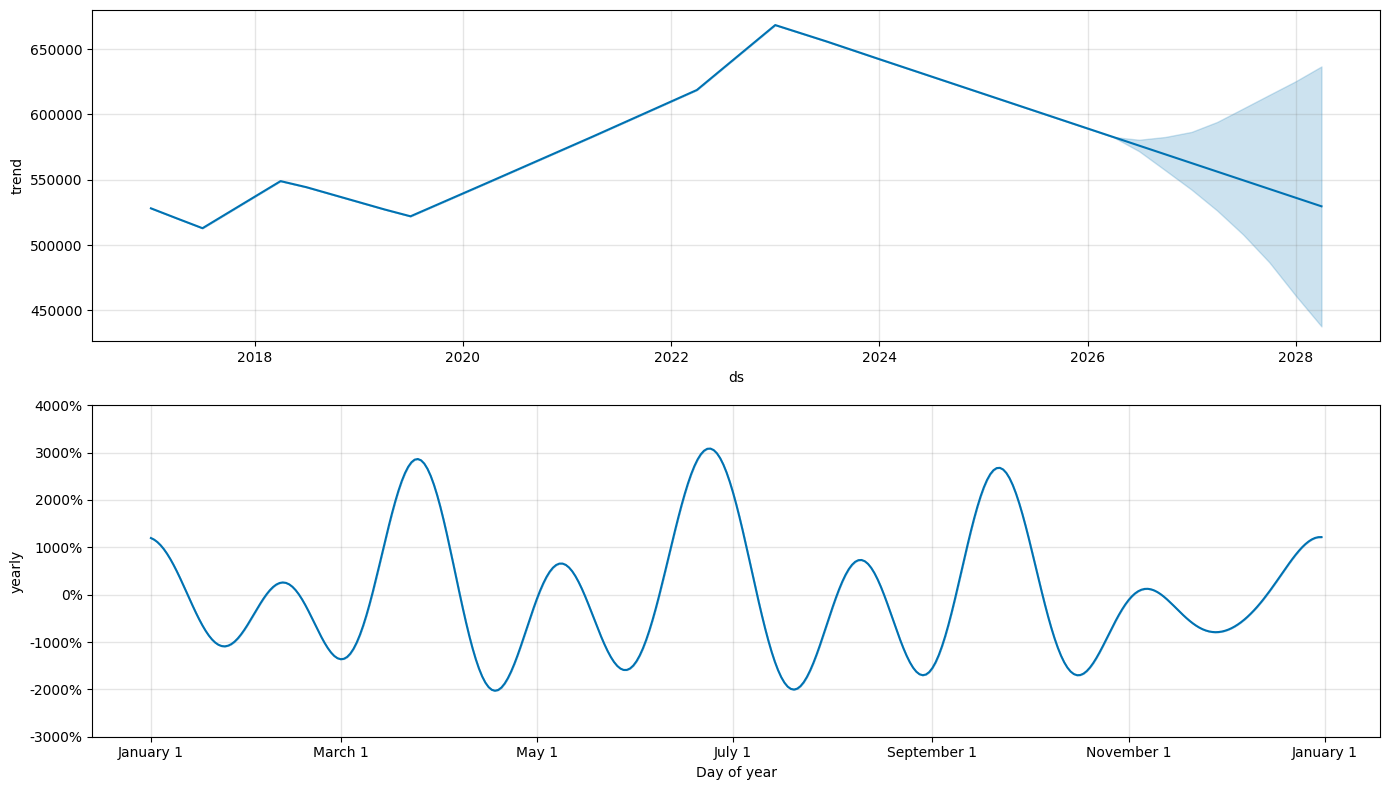

In [13]:
# Komponendid
fig = model.plot_components(forecast)
fig.set_size_inches(14, 8)
plt.tight_layout()



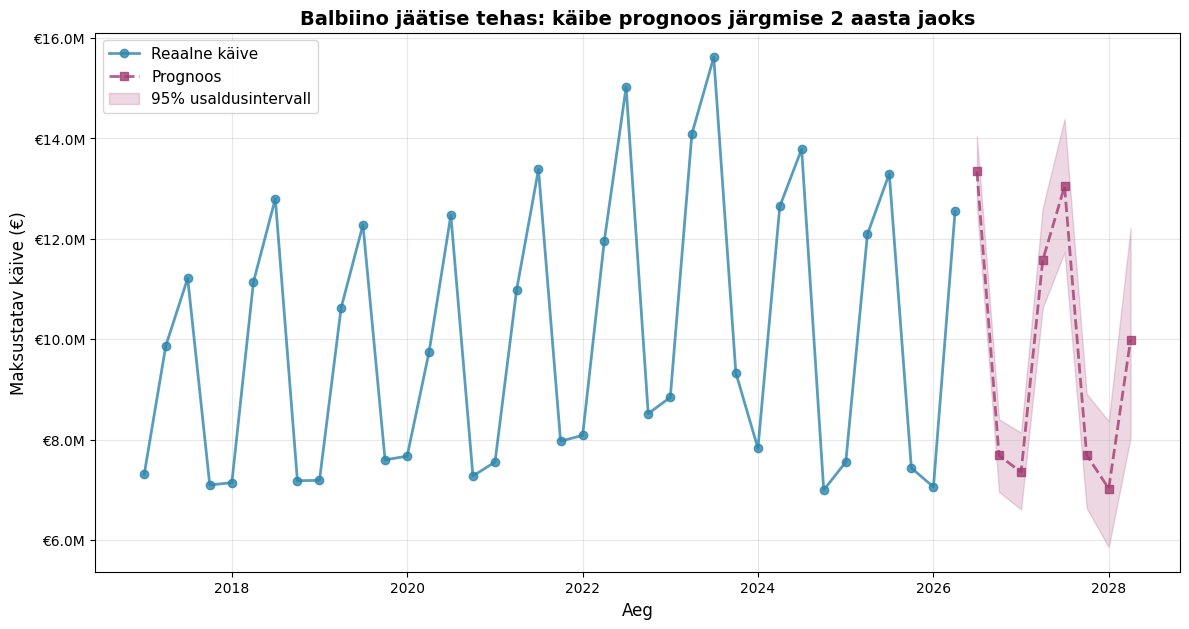

In [14]:
# Põhi-graafik: Reaalne vs Prognoos
fig, ax = plt.subplots(figsize=(14, 7))

# Ajalooandmed
ax.plot(df['ds'], df['y'], 'o-', linewidth=2, markersize=6, label='Reaalne käive', color='#2E86AB', alpha=0.8)

# Prognoos
forecast_future = forecast[forecast['ds'] > df['ds'].max()]
ax.plot(forecast_future['ds'], forecast_future['yhat'], 's--', linewidth=2, markersize=6, label='Prognoos', color='#A23B72', alpha=0.8)

# Usaldusintervall
ax.fill_between(
    forecast_future['ds'],
    forecast_future['yhat_lower'],
    forecast_future['yhat_upper'],
    alpha=0.2,
    color='#A23B72',
    label='95% usaldusintervall'
)

ax.set_xlabel('Aeg', fontsize=12)
ax.set_ylabel('Maksustatav käive (€)', fontsize=12)
ax.set_title('Balbiino jäätise tehas: käibe prognoos järgmise 2 aasta jaoks', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'€{x/1e6:.1f}M'))




In [ ]:
# Hooajasuunalisuus detail - näeme mustrit
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Kvartalikaupa keskmised
df['kvartal'] = df['ds'].dt.month.apply(lambda x: f'Q{(x-1)//3 + 1}')
quarterly_avg = df.groupby('kvartal')['y'].agg(['mean', 'std'])

ax1.bar(quarterly_avg.index, quarterly_avg['mean'], alpha=0.7, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'])
ax1.errorbar(quarterly_avg.index, quarterly_avg['mean'], yerr=quarterly_avg['std'], fmt='none', color='black', capsize=5)
ax1.set_ylabel('Keskmine käive (€)', fontsize=11)
ax1.set_xlabel('Kvartal', fontsize=11)
ax1.set_title('Hooajasuunalisuus: kvartalikaupa keskmised', fontsize=12, fontweight='bold')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'€{x/1e6:.1f}M'))
ax1.grid(True, alpha=0.3, axis='y')

# Hooajakomponent üksikud
seasonality_df = forecast[forecast['ds'] <= df['ds'].max()].copy()
seasonality_df['kvartal_nr'] = seasonality_df['ds'].dt.month.apply(lambda x: (x-1)//3 + 1)
seasonal_component = seasonality_df.groupby('kvartal_nr')['yearly'].mean()

ax2.plot(seasonal_component.index, seasonal_component.values, 'o-', linewidth=2.5, markersize=8, color='#2E86AB')
ax2.fill_between(seasonal_component.index, seasonal_component.values, alpha=0.3, color='#2E86AB')
ax2.set_xticks([1, 2, 3, 4])
ax2.set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'])
ax2.set_ylabel('Hooajakomponent (€)', fontsize=11)
ax2.set_xlabel('Kvartal', fontsize=11)
ax2.set_title('Prophet hooajakomponent', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'€{x/1e6:.1f}M'))

plt.tight_layout()
plt.savefig('/home/claude/hooajamuster.png', dpi=150, bbox_inches='tight')
print("✓ Hooajamustri graafik salvestatud")

# Müra/residuaalid
df_with_forecast = df.copy()
df_with_forecast = df_with_forecast.merge(forecast[['ds', 'yhat']], on='ds', how='left')
df_with_forecast['residuals'] = df_with_forecast['y'] - df_with_forecast['yhat']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Residuaalid ajas
ax1.scatter(df_with_forecast['ds'], df_with_forecast['residuals'], alpha=0.6, s=100, color='#E74C3C')
ax1.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
ax1.fill_between(df_with_forecast['ds'], 0, df_with_forecast['residuals'], alpha=0.2, color='#E74C3C')
ax1.set_ylabel('Residuaal (€)', fontsize=11)
ax1.set_xlabel('Aeg', fontsize=11)
ax1.set_title('Mudeli residuaalid ajas', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'€{x/1e6:.1f}M'))

# Residuaalide jaotus
ax2.hist(df_with_forecast['residuals'].dropna(), bins=12, alpha=0.7, color='#3498DB', edgecolor='black')
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Residuaal (€)', fontsize=11)
ax2.set_ylabel('Sagedus', fontsize=11)
ax2.set_title('Residuaalide jaotus', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'€{x/1e6:.1f}M'))

plt.tight_layout()
plt.savefig('/home/claude/residuaalid.png', dpi=150, bbox_inches='tight')
print("✓ Residuaalide graafik salvestatud")

# Mudeli kvaliteet
print()
print("📊 Mudeli Diagnoosika")
print("=" * 60)
print(f"Müra (RMSE): €{np.sqrt(np.mean(df_with_forecast['residuals'].dropna()**2)):,.0f}")
print(f"Müra (MAE): €{np.mean(np.abs(df_with_forecast['residuals'].dropna())):,.0f}")
print(f"Müra protsent (MAPE): {np.mean(np.abs(df_with_forecast['residuals'].dropna()/df_with_forecast['y']))*100:.1f}%")
print()